<a href="https://colab.research.google.com/github/guebin/PP2024/blob/main/posts/02wk-2.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" style="text-align: left"></a>

# 1. 강의영상

{{<video https://youtu.be/playlist?list=PLQqh36zP38-yhR5pDXI-Da8FHip-Pptur&si=E1GEXgXY51izjQSh >}}

# 2. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 3. 2024 수능 -- 16,11,8,26,19,12

![](https://github.com/guebin/PP2024/blob/main/imgs/2024-수능-16.png?raw=true)

In [147]:
#대략적인 값 확인 x=np.linspace(-5,5,101)
#x 

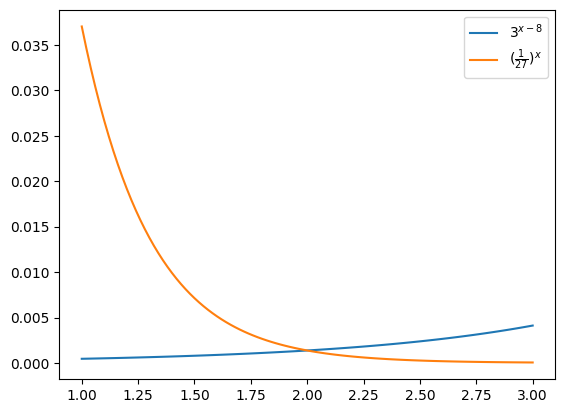

In [148]:
x=np.linspace(1,3,101) #처음 (-5,5,101) 임의로 출력해본 후 x, y 값을 조정해가며 만나는 점을 확인)
lhs = 3**(x-8)
rhs = (1/27)**x
plt.plot(x,lhs,label=r"$3^{x-8}$")
plt.plot(x,rhs,label=r"$(\frac{1}{27})^x$")
plt.legend()

In [149]:
#x=2라고 예상되는데, 한번 대입해보자.
3**(2-8), (1/27)**2

(0.0013717421124828531, 0.0013717421124828531)

In [150]:
#다른방식(유추 말고 직접 값을 구하기)
x = np.linspace(1,3,101)
lhs = 3**(x-8) 
rhs = (1/27)**x
#np.abs(lhs-rhs)
#np.argmin(np.abs(lhs-rhs)) *argument of minimum: 최솟값의 인덱스
x[np.argmin(np.abs(lhs-rhs))] #그때의 x 값 구하기

np.float64(2.0)

![](https://github.com/guebin/PP2024/blob/main/imgs/2024-수능-11.png?raw=true)

|a<sub>6</sub>| = a<sub>8</sub> 은
a<sub>6</sub> = a<sub>8</sub>, a<sub>6</sub> = -a<sub>8</sub> 을 의미.
그런데, 공차가 0이 아니므로 a<sub>6</sub> = a<sub>8</sub>는 불가능
또한 a<sub>6</sub> = -a<sub>8</sub> 라면 a<sub>7</sub> = 0이 성립


In [181]:
#수열을 만들 때, 아래와 같이 할 수 있지만 np.linspace 이용 가능
#n = np.array({1,2,3,4,5,6,7,8,9,10,11,12,13,14,15})
#n

In [ ]:
n = np.linspace(1,15,15)
#가령, 2*n-1 라고 하면 첫째항이 1이고, 공차가 2인 수열 만들어짐
d = 4
#d*n-d*7 7번째항이 0이 되도록 
np.stack([n,d*n-d*7],axis=1) #몇째항의 값이 무엇인지 알아보기 쉽게 정리

array([[  1., -24.],
       [  2., -20.],
       [  3., -16.],
       [  4., -12.],
       [  5.,  -8.],
       [  6.,  -4.],
       [  7.,   0.],
       [  8.,   4.],
       [  9.,   8.],
       [ 10.,  12.],
       [ 11.,  16.],
       [ 12.,  20.],
       [ 13.,  24.],
       [ 14.,  28.],
       [ 15.,  32.]])

(풀이1)

In [151]:
n = np.linspace(1,15,15)
d = 4
an = d*n-d*7
an

array([-24., -20., -16., -12.,  -8.,  -4.,   0.,   4.,   8.,  12.,  16.,
        20.,  24.,  28.,  32.])

좀 더 보기 편하게 하기 위해서..

In [152]:
np.stack([n,an],axis=1)

array([[  1., -24.],
       [  2., -20.],
       [  3., -16.],
       [  4., -12.],
       [  5.,  -8.],
       [  6.,  -4.],
       [  7.,   0.],
       [  8.,   4.],
       [  9.,   8.],
       [ 10.,  12.],
       [ 11.,  16.],
       [ 12.,  20.],
       [ 13.,  24.],
       [ 14.,  28.],
       [ 15.,  32.]])

$d$에 따라 바뀌는 $\sum_{k=1}^{5}\frac{1}{a_k a_{k+1}}$ 값을 조사하고 이 값이 $\frac{5}{96}$이 되는 $d$를 찾아보자.

In [ ]:
n = np.linspace(1,15,15)
d = 4
an = d*n-d*7
np.sum(1/(an[:5]*an[1:6])), 5/96  #d값을 변화시켜가며, 같아지는 값을 확인하기

(np.float64(0.052083333333333336), 0.052083333333333336)

찾아보니까 $d=4$이다.

In [154]:
np.sum(an)

np.float64(60.0)

::: {.callout-note}
`np.stack()`을 이용하는 부분은 너무 내용이 많아 이후에 다시 설명할 예정입니다. 이런것이 가능하다 정도만 알아두시고 이번퀴즈에서 공부하실때는 제외하세요.
:::

(풀이2)

In [155]:
n = np.linspace(1,15,15)
d = 4
an = d*n-d*7
print(f'{np.sum(1/(an[:5]*an[1:6]))-5/96} --> 이 값이 0이 되도록 해야함')

0.0 --> 이 값이 0이 되도록 해야함


구조를 살펴보니까

$$d \to np.sum(1/(an[:5]*an[1:6]))-5/96$$

와 같은 역할을 하는 함수 $dff(d)$를 선언하고 $dff(d)$가 0이 되는 $d$의 값을 찾으면 된다.

In [156]:
def dff(d):
    an = d*n-d*7
    return np.sum(1/(an[:5]*an[1:6]))-5/96

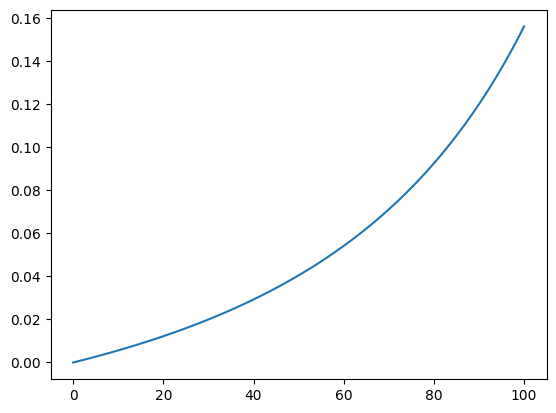

In [192]:
d = np.linspace(3,5,101)
#dff(0) 이런건 괜찮은데, dff([0.4, 0.5]) 이런식으로의 값을 원하지만, d와 n의 차원(?)이 달라서 이렇게는 나타낼 수 없음 
plt.plot(list(map(dff,d)))

조금 이해가 안되었는데 넘어감
복습/정리 시점에 다시 확인할 것.
- 11개 중 2번째 강의

In [158]:
dff_vector = list(map(dff,d))
d[np.argmin(np.abs(dff_vector))]

np.float64(4.0)

따라서 $d=4$에서  $dff(d)=\sum_{k=1}^{5}\frac{1}{a_k a_{k+1}}-\frac{5}{96}=0$이 만족한다. 따라서 답은

In [159]:
n = np.linspace(1,15,15)
d = 4
an = d*n-d*7
np.sum(an)

np.float64(60.0)

![](https://github.com/guebin/PP2024/blob/main/imgs/2024-수능-8.png?raw=true)

(풀이1)

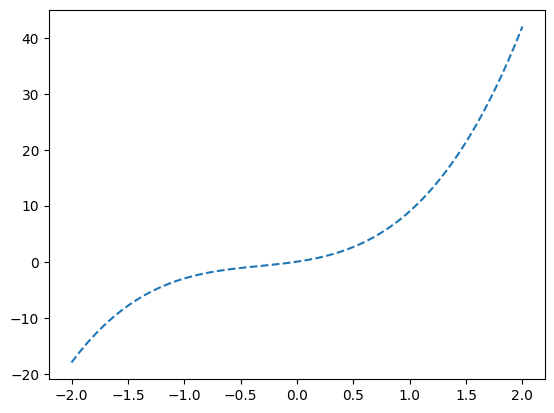

In [209]:
f = lambda x: (3*x**4 -3*x)/(x-1)
x = np.linspace(-2,2,100)
plt.plot(x,f(x),'--')

In [161]:
np.mean(f(x)) *4

np.float64(16.032032032032035)

(풀이2)

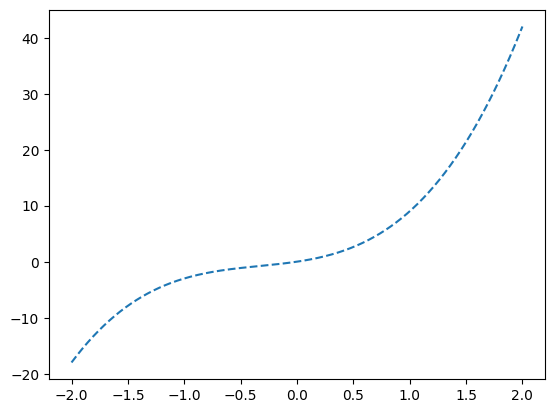

In [162]:
f = lambda x: (3*x**4 -3*x)/(x-1)
x = np.linspace(-2,2,1000)
plt.plot(x,f(x),'--')

직관적으로 생각해봤을 때, 
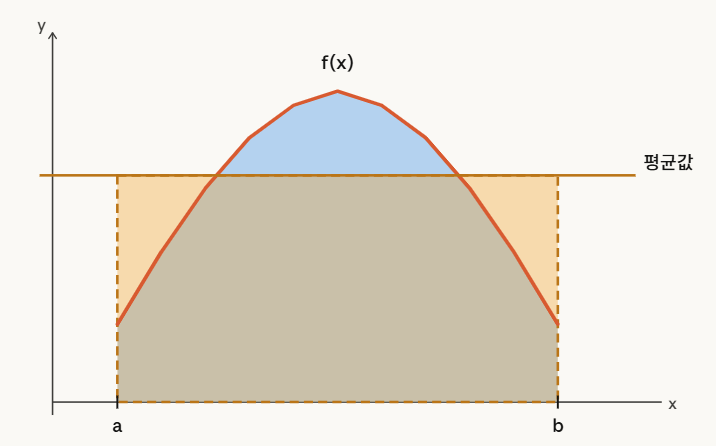{width=300px}

In [163]:
x_rand = np.random.rand(1000000)*4 - 2  ## -2~2 까지 임의의수가 골고루 퍼져있음.
np.mean(f(x_rand)) * 4

np.float64(16.033006347852663)

(풀이3)

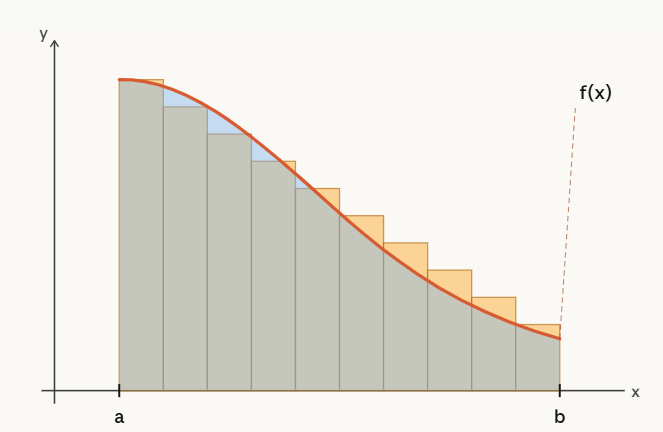{width=300px}

In [164]:
f = lambda x: (3*x**4 -3*x)/(x-1)
x = np.linspace(-2,2,1000)

In [165]:
delta = x[1]-x[0]
f_arr = f(x)
F_arr = np.cumsum(f_arr) * delta

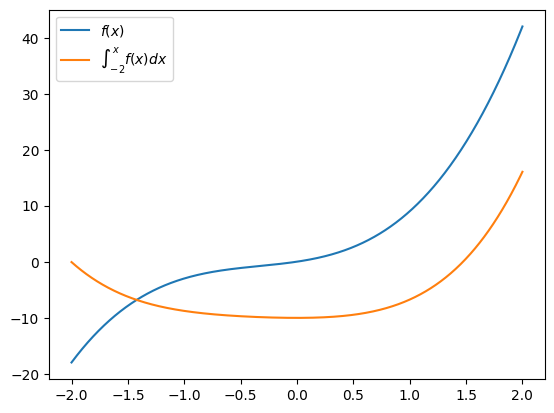

In [166]:
plt.plot(x,f_arr,label=r'$f(x)$')
plt.plot(x,F_arr,label=r'$\int_{-2}^{x}f(x)dx$')
plt.legend()

In [167]:
F_arr[-1]

np.float64(16.048080112143815)

![](https://github.com/guebin/PP2024/blob/main/imgs/2024-수능-미적-26.png?raw=true){width=500px}

(풀이)

In [168]:
x = np.linspace(3/4*np.pi, 5/4*np.pi, 101)
y = np.sqrt((1-2*x)*np.cos(x))

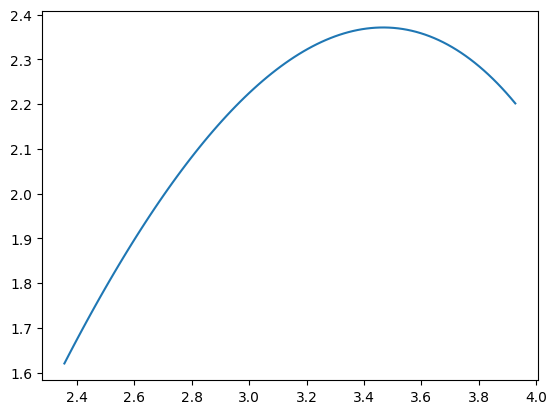

In [169]:
plt.plot(x,y)

In [213]:
np.mean(y**2) * 2/4*np.pi #정사각형의 넒이 * (5/4*np.pi-3/4*np.pi)

np.float64(7.4555248716100895)

In [171]:
np.sqrt(2)*np.pi-np.sqrt(2), np.sqrt(2)*np.pi-1, 2*np.sqrt(2)*np.pi-np.sqrt(2), 2*np.sqrt(2)*np.pi-1, 2*np.sqrt(2)*np.pi

(np.float64(3.028669375785271),
 np.float64(3.442882938158366),
 np.float64(7.471552313943637),
 np.float64(7.885765876316732),
 np.float64(8.885765876316732))

![](https://github.com/guebin/PP2024/blob/main/imgs/2024-수능-19.png?raw=true)

(풀이)

In [172]:
x = np.linspace(1,15,15)
f = lambda x: np.sin(np.pi/4*x)
bool_array = f(2+x)*f(2-x) < 1/4
bool_array

array([False,  True, False, False, False,  True, False, False, False,
        True, False, False, False,  True, False])

In [173]:
x[bool_array] # bool_array에서 True에 해당하는 원소들만 출력됨.

array([ 2.,  6., 10., 14.])

In [174]:
np.sum(x[bool_array])

np.float64(32.0)

![](https://github.com/guebin/PP2024/blob/main/imgs/2024-수능-12.png?raw=true){width=400px}

(풀이)

In [175]:
f = lambda x: 1/9*x*(x-6)*(x-9)
# note: 함수g는 t에 따라서 달라짐. t->g(x) 를 구현해주는 함수 make_gfunction 을 만들자.
def make_gfunction(t):
    def g(x):
        if x<t:
            return f(x)
        else:
            return -(x-t)+f(t)
    return g

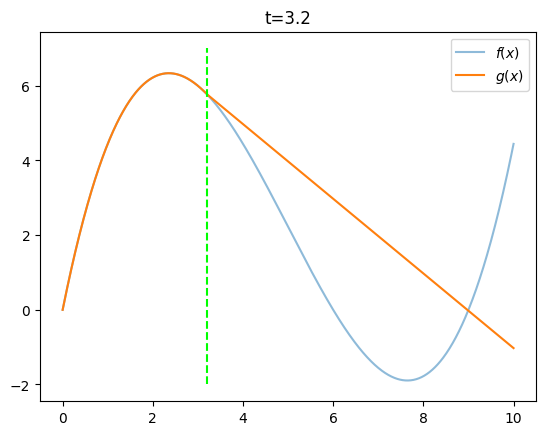

In [176]:
x = np.linspace(0,10,1001)
t = 3.2
g = make_gfunction(t)
fx = list(map(f,x))
gx = list(map(g,x))
plt.plot(x,fx,label=r'$f(x)$',alpha=0.5)
plt.plot(x,gx,label=r'$g(x)$')
plt.title(f"t={t}")
plt.vlines(t,ymin=-2,ymax=7,color='lime',linestyles='dashed')
plt.legend()

In [177]:
#t -> 주황색곡선의 면적이 계산되는 함수
def cal_area(t):
    #t = 3.2
    g = make_gfunction(t)
    fx = list(map(f,x))
    gx = list(map(g,x))
    Gx = np.cumsum(gx)*0.01
    S = np.max(Gx)
    return S

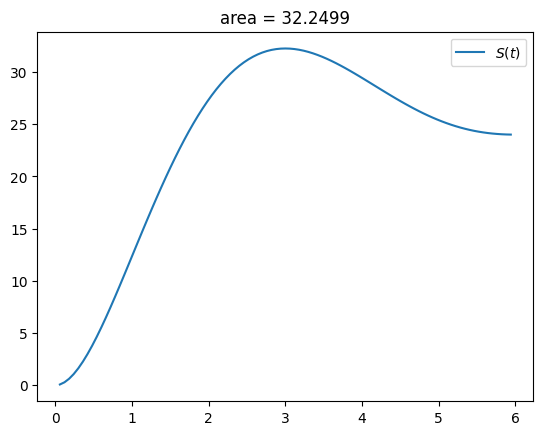

In [178]:
t = np.linspace(0,6,101)[1:-1]
St = list(map(cal_area,t))
plt.plot(t,St,label=r"$S(t)$")
plt.title(f'area = {np.max(St):.4f}')
plt.legend()

In [179]:
125/4, 127/4, 129/4, 131/4, 133/4

(31.25, 31.75, 32.25, 32.75, 33.25)

# 4. 자료형과 형변환 -- 파이썬 문법

`-` 파이썬의 기본자료형은 int, float, bool, str, list, tuple, dict, set 등이 있다.

- 0차원 자료형: int, float, bool
- 1차원 자료형: str, list, tuple, dict, set

## A. int, float, bool

`-` int형

In [34]:
a=100

In [35]:
type(a)

int

`-` float형

In [36]:
a=1.2*3
a

3.5999999999999996

In [37]:
type(a)

float

In [38]:
a?

`-` bool형

In [39]:
a=True ## 숫자1으로 생각할 수 있음
b=False ## 숫자0으로 생각할 수 있음

In [40]:
type(a)

bool

In [41]:
type(b)

bool

In [42]:
a?

In [43]:
b?

`-` bool형의 연산

In [44]:
a=True ## 1
b=False ## 0

In [45]:
a+b

1

In [46]:
a*b

0

`-` 형태변환: float $\to$ int

(예시1)

In [47]:
a=3.0
type(a)

float

In [48]:
a=int(a)

In [49]:
type(a)

int

(예시2) 이경우는 정보의 손실이 발생

In [50]:
a=3.14
int(a)

3

`-` 형태변환: int $\to$ float

In [51]:
a=3
type(a)

int

In [52]:
a=float(a)
type(a)

float

`-` 형태변환: bool $\to$ int/float, int/float $\to$ bool

(예시1)

In [53]:
a=True
type(a)

bool

In [54]:
int(a)

1

In [55]:
float(a)

1.0

(예시2)

In [56]:
a=1
bool(a)

True

In [57]:
a=0
bool(a)

False

(예시3)

In [58]:
a=1.0
bool(a)

True

In [59]:
a=0.0
bool(a)

False

## B. 1차원 자료의 형태변환

`-` list $\to$ np.array

In [60]:
[1,2,3]

[1, 2, 3]

In [61]:
np.array([1,2,3])

array([1, 2, 3])

`-` np.array $\to$ list

In [62]:
np.linspace(1,10,10)

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])

In [63]:
list(np.linspace(1,10,10))

[np.float64(1.0),
 np.float64(2.0),
 np.float64(3.0),
 np.float64(4.0),
 np.float64(5.0),
 np.float64(6.0),
 np.float64(7.0),
 np.float64(8.0),
 np.float64(9.0),
 np.float64(10.0)]

`-` range $\to$ list, np.array

In [64]:
range(10) # 이게 뭐야??

range(0, 10)

In [65]:
list(range(10)) # 리스트화

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [66]:
np.array(range(10)) # 넘파이배열화

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

***보충학습: range의 다양한 활용을 익혀보자.***

In [67]:
list(range(10))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [68]:
list(range(0,10))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [69]:
list(range(3,10))

[3, 4, 5, 6, 7, 8, 9]

In [70]:
list(range(3,10,2))

[3, 5, 7, 9]

`-` map 결과물 $\to$ list

In [71]:
f = lambda x: x**2
list(map(f,[1,2,3])) # [f(1),f(2),f(3)]

[1, 4, 9]

`-` map 결과물 $\to$ np.array로는 불가능

In [72]:
f = lambda x: x**2
np.array(map(f,[1,2,3]))

array(<map object at 0x7fd5c3b82ef0>, dtype=object)

In [73]:
# 아래는 가능
f = lambda x: x**2
np.array(list(map(f,[1,2,3])))

array([1, 4, 9])

# 5. 등차수열을 선언하는 다양한 방법 -- 파이썬 문법

아래와 같은 등차수열을 만드는 방법을 살펴보자.

$$1,4,7,\dots,31 $$

In [74]:
np.linspace(1,31,11)

array([ 1.,  4.,  7., 10., 13., 16., 19., 22., 25., 28., 31.])

In [75]:
list(range(1,32,3))

[1, 4, 7, 10, 13, 16, 19, 22, 25, 28, 31]

In [76]:
np.array(range(1,32,3))

array([ 1,  4,  7, 10, 13, 16, 19, 22, 25, 28, 31])

In [77]:
np.arange(1,32,3)

array([ 1,  4,  7, 10, 13, 16, 19, 22, 25, 28, 31])

In [78]:
# len(np.arange(1,32,3)) # 원소의 수는 11
n = np.arange(1,12)
3*n-2

array([ 1,  4,  7, 10, 13, 16, 19, 22, 25, 28, 31])

In [79]:
a = lambda n: 3*n-2
a(1),a(2),a(3),a(4),a(5),a(6),a(7),a(8),a(9),a(10),a(11)

(1, 4, 7, 10, 13, 16, 19, 22, 25, 28, 31)

In [80]:
n = np.arange(1,12)
a = lambda n: 3*n-2
a(n)

array([ 1,  4,  7, 10, 13, 16, 19, 22, 25, 28, 31])

In [81]:
n = np.arange(1,12)
a = lambda n: 3*n-2
list(map(a,n))

[np.int64(1),
 np.int64(4),
 np.int64(7),
 np.int64(10),
 np.int64(13),
 np.int64(16),
 np.int64(19),
 np.int64(22),
 np.int64(25),
 np.int64(28),
 np.int64(31)]

In [82]:
n = np.arange(32)
n[1::3]

array([ 1,  4,  7, 10, 13, 16, 19, 22, 25, 28, 31])

# 6. $\text{map}(f,{\bf x})$ -- 파이썬 문법

`-` 브로드캐스팅은 매우 편리한 기능임

In [83]:
f = lambda x: x+1

In [84]:
arr = np.array([1,2,3])
f(arr)

array([2, 3, 4])

`-` 불가능한 경우도 있음 (1)

In [85]:
f = lambda x: np.max(x) - np.min(x)

In [86]:
x1 = [1,2,3]
x2 = [2,3]
x3 = [3,3,4,5,5,6]
f(x1),f(x2),f(x3)

(np.int64(2), np.int64(1), np.int64(3))

In [87]:
list(map(f,[x1,x2,x3]))

[np.int64(2), np.int64(1), np.int64(3)]

`-` 불가능한 경우도 있었음 (2)

In [88]:
def dff(d):
    n = np.linspace(1,15,15)
    an = d*n-d*7
    return np.sum(1/(an[:5]*an[1:6]))-5/96

In [89]:
d = 1
dff(d)

np.float64(0.78125)

이게 되는이유?

In [90]:
d = 1
n = np.linspace(1,15,15)
an = d*n-d*7
np.sum(1/(an[:5]*an[1:6]))-5/96

np.float64(0.78125)

In [91]:
d = np.array([1,2,3])
dff(d)

ValueError: operands could not be broadcast together with shapes (3,) (15,) 

이게 안되는 이유?

In [ ]:
d = np.array([1,2,3])
n = np.linspace(1,15,15)
an = d*n-d*7
np.sum(1/(an[:5]*an[1:6]))-5/96

ValueError: operands could not be broadcast together with shapes (3,) (15,) 

`-` 그동안 가능했던 이유

In [ ]:
def f(x):
    return x+1

In [ ]:
x=5
x+1

6

In [ ]:
x=np.array([5,6])
x+1

array([6, 7])

> 요약: 어떠한 함수가 원소별로 각각 적용은 가능하지만 한번에 적용 (브로드캐스팅) 은 불가능할때 map은 매우 강력한 도구이다.

# 7. Bool을 이용한 인덱싱 -- 파이썬 문법

`-` 기본개념

In [ ]:
arr = np.array([1,-2,3,44])
arr[[True,False,True,True]]

array([ 1,  3, 44])

`-` 응용 1 -- 양수만 출력

In [ ]:
arr = np.array([1,-2,3,44])
arr[arr>0]

array([ 1,  3, 44])

`-` 응용 2 -- 짝수만 출력

In [ ]:
arr = np.array([1,-2,3,44])
arr[arr % 2 == 0]

array([-2, 44])

***보충학습: 아래의 테크닉도 알아둘것***

`-` 예시1 -- 양수를 카운트

In [ ]:
arr = np.array([1,-2,3,44])
sum(arr>0)

3

`-` 예시2 -- 짝수를 카운트

In [ ]:
arr = np.array([1,-2,3,44])
sum(arr % 2 == 0)

2

# 8. if문 -- 파이썬 문법

`-` 예시1

In [ ]:
def f(x):
    if x>0:
        return x
    else:
        return -x

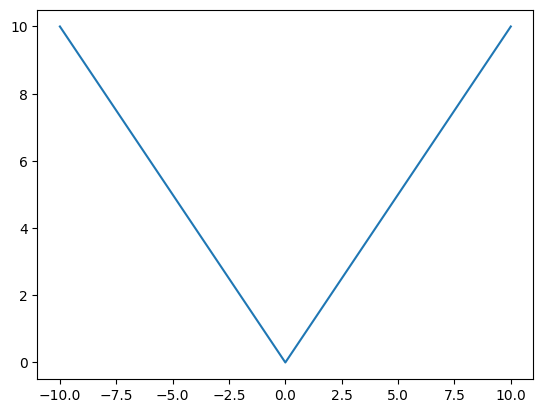

In [ ]:
x = np.linspace(-10,10,101)
fx = np.array(list(map(f,x)))
plt.plot(x,fx)

`-` 예시2

In [ ]:
def f(x):
    return x if x>0 else -x

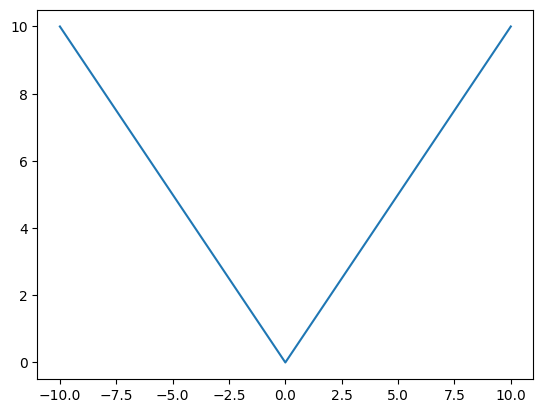

In [ ]:
x = np.linspace(-10,10,101)
fx = np.array(list(map(f,x)))
plt.plot(x,fx)

`-` 예시3

In [ ]:
f = lambda x: x if x>0 else -x

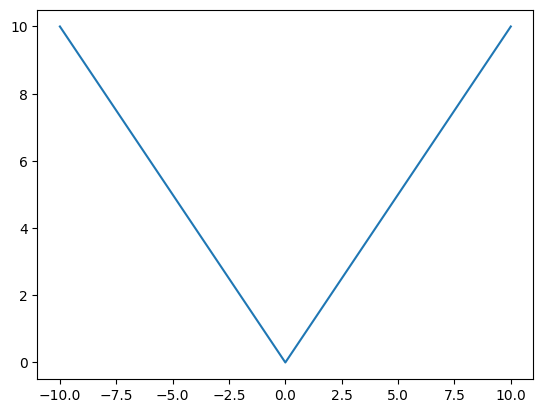

In [ ]:
x = np.linspace(-10,10,101)
fx = np.array(list(map(f,x)))
plt.plot(x,fx)

# 9. np.random 모듈 -- 파이썬 문법

## A. np.random.rand()

`-` 0~1 사이에서 10개의 난수생성

In [ ]:
np.random.rand(10)

array([0.43345371, 0.48324862, 0.48046707, 0.41056049, 0.56188841,
       0.58762904, 0.6645858 , 0.60568829, 0.83033841, 0.4660302 ])

`-` 0~2 사이에서 10개의 난수생성

In [ ]:
np.random.rand(10)*2

array([0.44894259, 1.8416822 , 0.50164259, 1.01601855, 0.21073439,
       1.8049244 , 0.86548008, 0.38544391, 0.13816874, 1.22858088])

`-` 1~3 사이에서 10개의 난수생성

In [ ]:
np.random.rand(10)*2 + 1

array([1.58013021, 1.96358901, 2.62137695, 1.74617053, 2.38021729,
       1.00043864, 1.42801985, 1.65666288, 2.80405753, 1.23691426])

## B. np.random.randn()

`-` N(0,1)에서 10개의 난수생성

In [ ]:
np.random.randn(10) # 표준정규분포에서 10개의 샘플 추출

array([-0.88043002, -0.75000612, -0.46393189,  0.73721724, -0.66208613,
        0.84740615, -0.31835775,  0.60157946,  0.62744116,  2.06223706])

`-` N(1,1)에서 10개 난수생성

In [ ]:
np.random.randn(10) + 1

array([ 1.50801901,  0.06945884,  2.52305677,  0.25080242, -0.25058225,
        1.81696343, -0.47341629,  0.51879014,  2.55038708,  0.58788704])

`-` N(0,4) 에서 10개 난수생성

In [ ]:
np.random.randn(10)*2

array([-2.26593271, -1.62304968, -1.71372316,  2.93723947,  0.63497107,
        2.96605112,  0.71536533,  2.64037886,  0.10782247, -2.97822434])

`-` N(3,4) 에서 10개 난수생성

In [ ]:
np.random.randn(10)*2+3

array([ 3.71923104,  1.77496469,  4.04116354,  4.27443252,  2.59130929,
        5.48551961, -1.09164073,  3.08090641,  0.88721243,  3.34579357])

## C. np.random.randint()

`-` [0,7) 에서 10개의 정수생성

In [ ]:
np.random.randint(0,7,size=10) # [0,7)의 범위에서 10개의 정수 생성

array([0, 1, 5, 0, 2, 3, 1, 3, 0, 5])

`-` [10,20) 에서 10개의 정수생성

In [ ]:
np.random.randint(10,20,size=10) # [0,7)의 범위에서 10개의 정수 생성

array([11, 10, 10, 19, 13, 11, 11, 11, 15, 19])

## D. np.random.choice()

`-` [11,22,33] 에서 중복허용하여 20개 추출

In [ ]:
np.random.choice([11,22,33],20)

array([33, 33, 11, 33, 11, 11, 33, 22, 11, 33, 33, 33, 22, 33, 11, 11, 22,
       22, 33, 22])

`-` [11,22,33] 에서 중복허용하여 3개 추출

In [ ]:
np.random.seed(4)
np.random.choice([11,22,33],3)

array([33, 33, 22])

In [ ]:
np.random.seed(5)
np.random.choice([11,22,33],3)

array([33, 22, 33])

`-` [11,22,33] 에서 중복허용하지 않고 3개 추출

In [ ]:
np.random.choice([11,22,33],3,replace=False)

array([22, 33, 11])

# 10. 함수를 리턴하는 함수 -- 파이썬 문법

`-` 예제1: $(P,Q)$를 입력으로 받아, 기울기가 2이고 점 $(P,Q)$를 지나는 함수를 리턴하는 함수를 구현하라.

In [ ]:
def make_func(p,q):
    def func(x):
        return 2*(x-p)+q
    return func

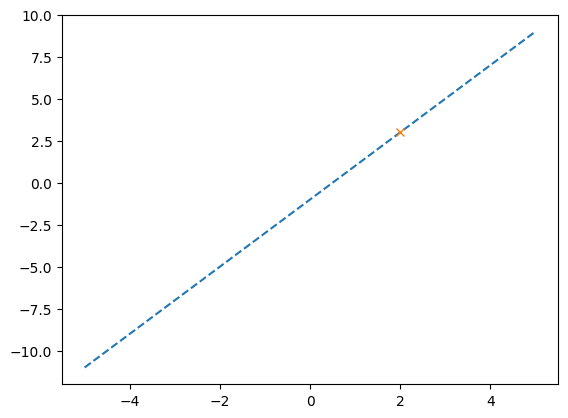

In [ ]:
x = np.linspace(-5,5,101)
p,q = 2,3
f = make_func(p,q)
plt.plot(x,f(x),'--')
plt.plot([p],[q],'x')

`-` 예제2: $f(x)=x^2$ 위의 임의의 점을 입력하면 접선을 리턴하는 함수를 구현하라.

In [ ]:
def make_func(x0):
    f = lambda x: x**2
    def func(x):
        h = 0.0001
        a = (f(x0+h)-f(x0))/h
        return a*(x-x0) + f(x0)
    return func

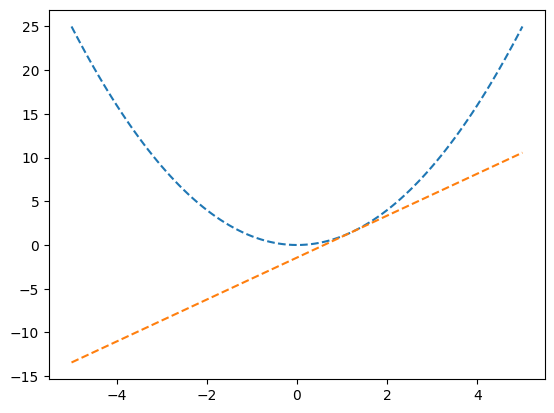

In [ ]:
x = np.linspace(-5,5,101)
tan_line = make_func(1.2)
plt.plot(x,x**2,'--')
plt.plot(x,tan_line(x),'--')